In [1]:
import numpy as np
from scipy import stats

# X = np.array([4.0, 4.0, 3.5, 4.0, 2.0, 2.5, 1.5])
# Y = np.array([1.0, 0.5, 2.0, 2.0, 3.5, 3.0, 4.0])
#
# # %%
# ## Printing sums of X and Y
# print(np.sum(X))
# print(np.sum(Y))
# print(np.sum(X**2))
# print(np.sum(X * Y))
#
# # %%
# # model achieved
# theta_0 = 5.781
# theta_1 = -1.138
#
#
# def y(x):
#     return theta_0 + theta_1 * x
#
#
# epsilon = Y - y(X)
# print(epsilon)
# print(epsilon**2)
#
# # %%
# # variance is then
# sigma_2 = (np.sum(epsilon**2)) / (len(Y) - 2)
# print(sigma_2)
# # sigma^2 = 0.245
#
# # %%
#

# Exercise 3.1 and 3.2

In [2]:
# 1. Input the data from Table 3.2 [4]
t = np.array([5 - 11])
y = np.array([1.0, 0.5, 2.0, 2.0, 3.5, 3.0, 4.0])
x_vals = np.array([4.0, 4.0, 3.5, 4.0, 2.0, 2.5, 1.5])

In [3]:
# 2. Set up the Design Matrix (x) and Observation Vector (Y) [1]
# We add a column of 1s to account for the intercept (theta_0)
N = len(y)
p = 2  # Number of parameters (intercept and slope)
X = np.column_stack((np.ones(N), x_vals))
Y = y.reshape(-1, 1)

In [4]:
# 3. Estimate Parameters (theta_hat) using Theorem 3.1 [1]
# theta_hat = (X^T * X)^-1 * X^T * Y
xtx = X.T @ X
xtx_inv = np.linalg.inv(xtx)
theta_hat_x = xtx_inv @ X.T @ Y

intercept, slope = theta_hat_x.flatten()
print(f"Model: Y_hat = {intercept:.3f} + ({slope:.3f}) * x")

Model: Y_hat = 5.782 + (-1.138) * x


In [5]:
# 4. Estimate Noise Variance (sigma_hat^2) using Theorem 3.4 [12]
residuals = Y - (X @ theta_hat_x)
sse = np.sum(residuals**2)
sigma_sq_hat = sse / (N - p)
sigma_hat = np.sqrt(sigma_sq_hat)

In [6]:
# 5. Predict for a new x value (e.g., x_8 = 0.5 from Exercise 3.1) [4]
x_new_val = 0.5
x_new = np.array([1, x_new_val])
y_pred = x_new @ theta_hat_x

In [7]:
# 6. Calculate 95% Prediction Interval using Theorem 3.10 & Eq 3.61 [2, 3]
# alpha = 0.05 for 95% confidence
alpha = 0.1
df = N - p
t_val = stats.t.ppf(1 - alpha / 2, df)  # This replaces the need for t-tables

# Scaling factor: sqrt(1 + x_new^T * (X^T * X)^-1 * x_new)
margin_sq = 1 + x_new.T @ xtx_inv @ x_new
margin_error = t_val * sigma_hat * np.sqrt(margin_sq)

lower_bound = y_pred - margin_error
upper_bound = y_pred + margin_error

print(f"\nPrediction for x = {x_new_val}: {y_pred}")
print(f"90% Prediction Interval: [{lower_bound}, {upper_bound}]")


Prediction for x = 0.5: [5.21276596]
90% Prediction Interval: [[3.75570202], [6.6698299]]


# Ex. 3.1.3 Univariate Time Series
Assume that we have observed only the time series {yt}. Using
this assumption, calculate a 90% confidence interval for Y8.

First we will construct a simple linear regression model but instead of using x as the predictor we will use the time index t. This means that we will be modeling the trend in the data. We can then use this model to predict Y8 and construct a confidence interval around this prediction.

$Y_t = \theta_0 + \theta_1 t + \epsilon_t$

In [8]:
import numpy as np
from scipy import stats

In [9]:
# Construct time model
y_obs = np.array([1.0,0.5,2.0,2.0,3.5,3.0,4.0])
t_obs = np.arange(1, 8)  # t = 1, 2, ..., 7


In [10]:
# 2. Set up the Design Matrix (x) and Observation Vector (Y) [1]
# We add a column of 1s to account for the intercept (theta_0)
N = len(y_obs)
p = 2  # Number of parameters (intercept and slope)
T = np.column_stack((np.ones(N), t_obs))
Y = y_obs.reshape(-1,1)

In [11]:
print(T)

[[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]
 [1. 6.]
 [1. 7.]]


$\hat{\theta} = (T^T T)^{-1} T^T Y$

In [12]:
ttt = T.T @ T
ttY = T.T @ Y

theta_hat_t = np.linalg.inv(ttt) @ ttY
print(theta_hat_t)
theta_0 , theta_1 = theta_hat_t.flatten()
print(f"theta 0 is {theta_0}")
print(f"theta 1 is {theta_1}")

[[0.07142857]
 [0.55357143]]
theta 0 is 0.07142857142857117
theta 1 is 0.5535714285714284


In [13]:
def y_time_model(t):
    return theta_0 + theta_1 * t



In [14]:
# 4. Estimate Noise Variance (sigma_hat^2) using Theorem 3.4 [12]
residuals = Y - (T @ theta_hat_t)
sse = np.sum(residuals**2)
sigma_sq_hat = sse / (N - p)
sigma_hat = np.sqrt(sigma_sq_hat)

In [15]:
# 5. Predict for a new x value (e.g., x_8 = 0.5 from Exercise 3.1) [4]
t_new_val = 8
t_new = np.array([1, t_new_val])
y_pred = t_new @ theta_hat_t


In [16]:
# 6. Calculate 95% Prediction Interval using Theorem 3.10 & Eq 3.61 [2, 3]
# alpha = 0.05 for 95% confidence
alpha = 0.1
df = N - p
t_val = stats.t.ppf(1 - alpha / 2, df)  # This replaces the need for t-tables

# Scaling factor: sqrt(1 + t_new^T * (X^T * X)^-1 * t_new)
margin_sq = 1 + t_new.T @ np.linalg.inv(ttt) @ t_new
margin_error = t_val * sigma_hat * np.sqrt(margin_sq)

lower_bound = y_pred - margin_error
upper_bound = y_pred + margin_error

print(f"\nPrediction for t = {t_new_val}: {y_pred}")
print(f"90% Prediction Interval: [{lower_bound}, {upper_bound}]")


Prediction for t = 8: [4.5]
90% Prediction Interval: [[3.12999693], [5.87000307]]


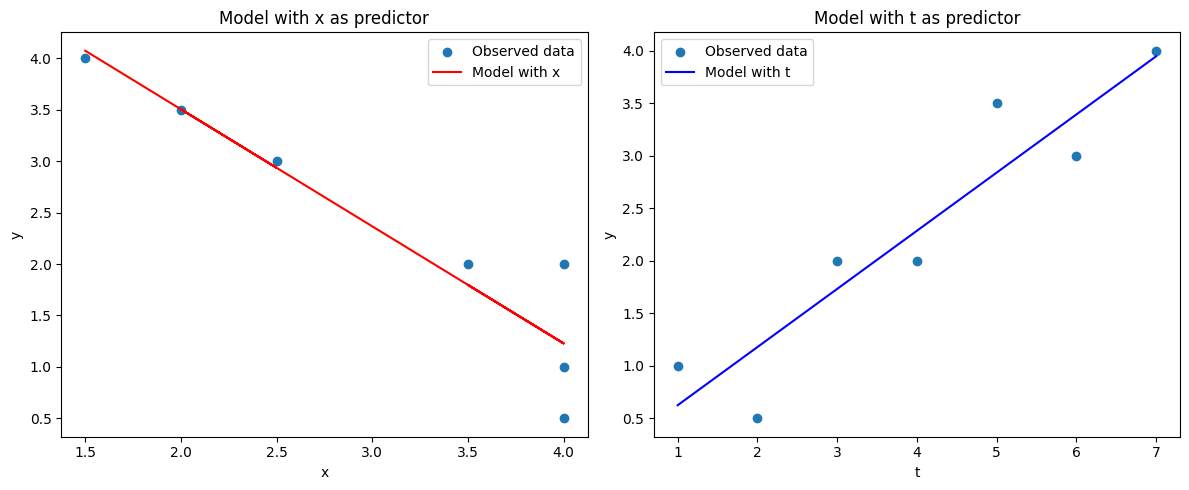

In [17]:
# Plot the 2 different models (1 model on x and 1 model on t)
import matplotlib.pyplot as plt

y_obs = np.array([1.0,0.5,2.0,2.0,3.5,3.0,4.0])
x_obs = x_vals
t_obs = np.arange(1, 8)  # t = 1

def y_model_x(x):
    return theta_hat_x[0] + theta_hat_x[1] * x

y_pred_x = y_model_x(x_obs)

def y_model_t(t):
    return theta_hat_t[0] + theta_hat_t[1] * t
y_pred_t = y_model_t(t_obs)



# Model 1: Using x as predictor
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(x_obs, y_obs, label='Observed data')
plt.plot(x_obs, y_pred_x, color='red', label='Model with x')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Model with x as predictor')
plt.legend()

# Model 2: Using t as predictor
plt.subplot(1, 2, 2)
plt.scatter(t_obs, y_obs, label='Observed data')
plt.plot(t_obs, y_pred_t, color='blue', label='Model with t')
plt.xlabel('t')
plt.ylabel('y')
plt.title('Model with t as predictor')
plt.legend()

plt.tight_layout()
plt.show()

___

Exercise 3.4
In an airport near Copenhagen the, wind speed is measured every hour using a cup-anemometer. Suppose that now ( $t=8$ ) the following observations of the wind speed are given $[\mathrm{m} / \mathrm{s}]$ :

$$
4.4,3.4,3.3,2.5,7.3,4.9,4.8,4.4
$$


Before the fifth measurement was performed, the anemometer was moved from the normal measuring location ( 2 m above ground level) to the roof of a building.

### Question 1: Formulate a suitable model describing describing the variations in the observed wind speeds.

We can try to predict a trend in the data by using a simple linear regression model with time as the predictor. This will allow us to see if there is an increasing or decreasing trend in the wind speeds over time. 

$$ Y_t = T \theta + \epsilon_t $$

This leads us to the following model:

$$ Y_t = \theta_0 + \theta_1 t + \epsilon_t $$

Where $Y_t$ is the observed wind speed at time t, T is the design matrix containing the time indices, $\theta$ is the parameter vector we want to estimate, and $\epsilon_t$ is the error term.

In [18]:
from numpy import reshape


wind_obs = np.array([4.4,3.4,3.3,2.5,7.3,4.9,4.8,4.4])
Y = wind_obs.reshape(-1,1)
t = np.arange(1,9)
T = np.column_stack((np.ones(len(t)), t))


ttt = T.T @ T
ttt_inv = np.linalg.inv(ttt)
ttY = T.T @ Y

theta_hat = ttt_inv @ ttY

print(theta_hat)

intercept, slope = theta_hat
print(f"Model: Y_hat = {intercept} + ({slope}) * t")

[[3.48571429]
 [0.19761905]]
Model: Y_hat = [3.48571429] + ([0.19761905]) * t


In [19]:
def naive_slope(t):
    return intercept + slope * t

so we do see a trend going up


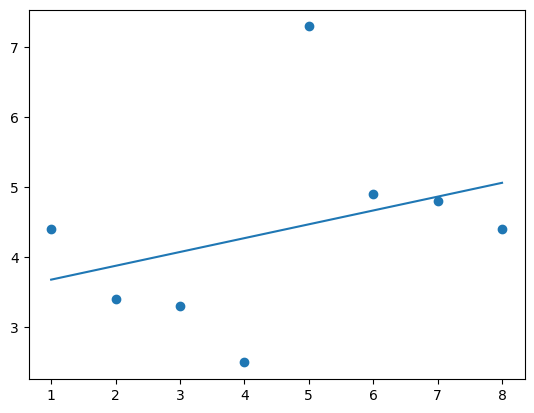

In [20]:
import matplotlib.pyplot as plt

plt.scatter(t, wind_obs)
plt.plot(t,naive_slope(t))

print(f"so we do see a trend going up")

### Solve question 3.4.2 by step intervention model 

Question 2 Estimate the parameters of the model and especially assess (model)
the diﬀerence in wind speed at the two measurement locations.

We wish to determine the mean wind speed at the normal measuring location (2 m above ground level) and the mean wind speed at the roof of the building. We can do this by estimating the parameters of our linear regression model. but by including an indicator variable that captures the change in location after the fifth measurement. This will allow us to assess the difference in wind speed between the two locations.

$$ Y_t = \theta_0 + \theta_1 t + \theta_2 D_t + \epsilon_t$$

Where $D_t$ is an indicator variable that is 0 for the first 4 measurements (normal location) and 1 for the last 4 measurements (roof location).

in matrix form this can be written as:
$$
Y = X \theta + \epsilon
$$

Where Y is the vector of observed wind speeds, X is the design matrix that includes the time indices and the indicator variable, $\theta$ is the parameter vector we want to estimate, and $\epsilon$ is the error term.

and if we expand the design matrix X it will look like this:
$$
X = \begin{bmatrix}
1 & 1 & 0 \\
1 & 2 & 0 \\
1 & 3 & 0 \\
1 & 4 & 0 \\
1 & 5 & 1 \\
1 & 6 & 1 \\
1 & 7 & 1 \\
1 & 8 & 1 \\
\end{bmatrix}
$$


In [21]:
y_obs = wind_obs
dummy = np.array([0,0,0,0,1,1,1,1])
x_obs = np.arange(1,9)
X = np.column_stack((np.ones(len(x_obs)), x_obs, dummy))
print(X)

Y = y_obs.reshape(-1,1)
print(Y)

[[1. 1. 0.]
 [1. 2. 0.]
 [1. 3. 0.]
 [1. 4. 0.]
 [1. 5. 1.]
 [1. 6. 1.]
 [1. 7. 1.]
 [1. 8. 1.]]
[[4.4]
 [3.4]
 [3.3]
 [2.5]
 [7.3]
 [4.9]
 [4.8]
 [4.4]]


Solution to the model 
$$ \hat{\theta} = (X^T X)^{-1} X^T Y $$

In [28]:
xtx = X.T @ X
xty = X.T @ Y

theta_hat = np.linalg.inv(xtx) @ xty

print(theta_hat)

intercept, slope, diff = theta_hat.flatten()

print(f"the model is y = {intercept} + {slope} * t + {diff} * '{1, 0}'")

[[ 5.225]
 [-0.73 ]
 [ 4.87 ]]
the model is y = 5.225000000000005 + -0.7300000000000004 * t + 4.869999999999997 * '(1, 0)'


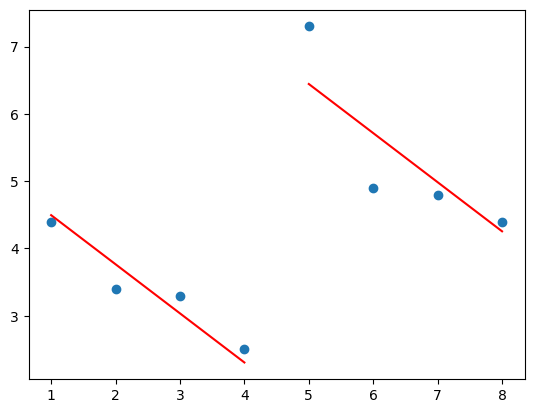

In [31]:
import matplotlib.pyplot as plt

old = np.arange(1,5)
new = np.arange(5,9)

def old_location_wind_pred(t):
    return intercept + slope * t + (diff * 0)

def new_location_wind_pred(t):
    return intercept + slope * t + (diff * 1)
plt.scatter(x_obs, y_obs)
plt.plot(old, old_location_wind_pred(old), color='r')
plt.plot(new, new_location_wind_pred(new), color='r')
plt.show()


In [ ]:
old_location_wind_pred(9)

np.float64(-1.3449999999999989)